In [47]:
!pip install mglearn

In [48]:
import mglearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import numpy as np


In [49]:
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [50]:
# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [51]:
# Linear Regression Model Scores
print("Train set R^s Score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set R^s Score: {:.2f}". format(lr.score(X_test, y_test)))

Train set R^s Score: 0.94
Test set R^s Score: 0.78


# Ridge Regression

In [52]:
# Ridge Regression Model
ridge = Ridge()
ridge.fit(X_train, y_train)

Ridge()

In [53]:
# Ridge Regression Model Scores
print("Train set R^s Score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set R^s Score: {:.2f}". format(ridge.score(X_test, y_test)))

Train set R^s Score: 0.87
Test set R^s Score: 0.81


We can see that the training set score of Ridge model is lower than that of LinearRegession model(0.94), While the test score is higher.


 With linear regression, we were overfitting our data. Ridge is a more restricted model, so we are less likely to overfit. A less complex model means worse performance on the training set, but better generalization. As we are only interested in generalization performance, we should choose the Ridge model over the LinearRegression model.

The Ridge model makes a trade-off between the simplicity of the model (near-zero coefficients) and its performance on the training set. How much importance the model places on simplicity versus training set performance can be specified by the user, using the **alpha** parameter.

In above example we used the default parameter which is alpha = 1.0.

The optimum setting of alpha depends on the particular dataset we are using.

**Increasing alpha** forces coefficients to move more toward zero, which decreases training set performance but might help generalization. Below is an example:



In [54]:
# Ridge Regression Model with increased aplha
ridge10 = Ridge(alpha=10)
ridge10.fit(X_train, y_train)

Ridge(alpha=10)

In [55]:
# Ridge Regression Model Scores with increased aplha
print("Training set R^s Score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Testing set R^s Score: {:.2f}".format(ridge10.score(X_test, y_test)))

Training set R^s Score: 0.77
Testing set R^s Score: 0.73


**Decreasing alpha** allows the coefficients to be less restricted, meaning we move right in Figure 2-1. For very small values of alpha, coefficients are barely restricted at all, and we end up with a model that resembles LinearRegression. Below is an example.

In [56]:
# Ridge Regression Model with decreased alpha
ridge01 = Ridge(alpha=0.1)
ridge01.fit(X_train, y_train)

Ridge(alpha=0.1)

In [57]:
# Ridge Regression Model Scores with decreased alpha
print("Training set R^s Score: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Testing set R^s Score: {:.2f}".format(ridge01.score(X_test, y_test)))

Training set R^s Score: 0.92
Testing set R^s Score: 0.82


From the values tried so far, a smaller alpha gave better test performance, so it might be worth trying even smaller values to see if generalization improves further.

Below plot give more qualitative insight into how the alpha parameter changes the model by inspecting the coef_ attribute of models with different values of alpha. A higher alpha means a more restricted model, so we expect the entries of coef_ to have smaller magnitude for a high value of alpha than for a low value of alpha

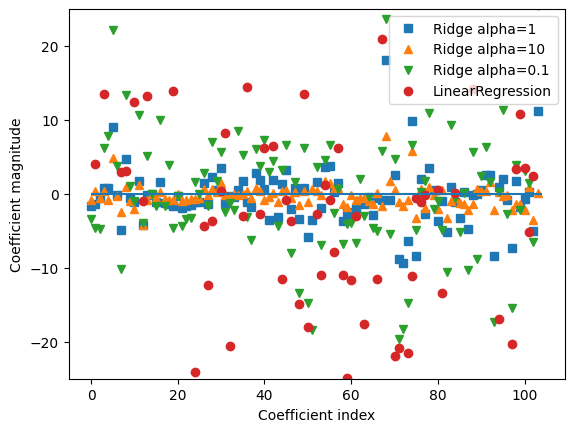

In [58]:
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")

plt.plot(lr.coef_, 'o', label="LinearRegression")
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")
plt.hlines(0, 0, len(lr.coef_))
plt.ylim(-25, 25)
plt.legend()

Here, the x-axis enumerates the entries of coef_: x=0 shows the coefficient associated with the first feature, x=1 the coefficient associated with the second feature, and so on up to x=100. The y-axis shows the numeric values of the corresponding values of the coefficients. The main takeaway here is that for alpha=10, the coefficients are mostly between around –3 and 3. The coefficients for the Ridge model with alpha=1, are somewhat larger. The dots corresponding to alpha=0.1 have larger magnitude still, and many of the dots corresponding to linear regression without any regularization (which would be alpha=0) are so large they are outside of the chart.

Another way to understand the influence of regularization is to fix a value of alpha but vary the amount of training data available.

Below example visualizes it (subsampled the Boston Housing dataset and evaluated LinearRegression and Ridge(alpha=1) on subsets of increasing size ),

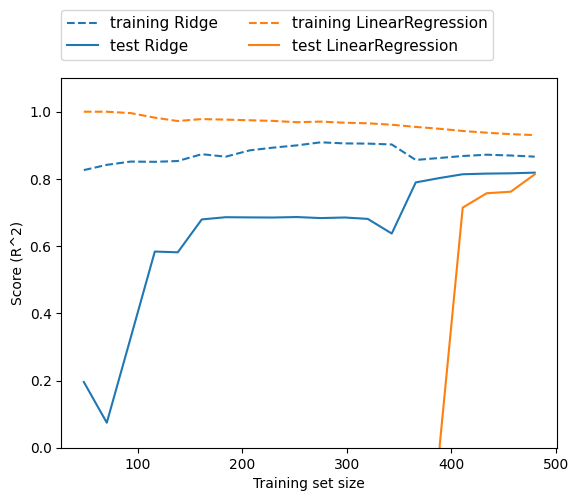

In [59]:
mglearn.plots.plot_ridge_n_samples()

As expected the training score is higher than the test score for all dataset sizes, for both ridge and linear regression. Because ridge is regularized, the training score of ridge is lower than the training score for linear regression across the board. However, the test score for ridge is better, particularly for small subsets of the data. For less than 400 data points, linear regression is not able to learn anything. As more and more data becomes available to the model, both models improve, and linear regression catches up with ridge in the end.

* The lesson here is that with enough training data, regularization becomes less important, and given enough data, ridge and linear regression will have the same performance (the fact that this happens here when using the full dataset is just by chance).

* The other important thing is the decrease in training performance for linear regression. If more data is added, it becomes harder for a model to overfit, or memorize the data.

# Lasso Regression

In [60]:
lasso = Lasso()
lasso.fit(X_train, y_train)

Lasso()

In [61]:
print("Training set R^s Score: {:.2f}".format(lasso.score(X_train, y_train)))
print("Test set R^s Score: {:.2f}".format(lasso.score(X_test, y_test)))
print("No.of features used: ", np.sum(lasso.coef_ != 0)) #counts No.of features with non-zero coefficients

Training set R^s Score: 0.27
Test set R^s Score: 0.26
No.of features used:  3


As we can see, Lasso does quite badly, both on the training and the test set. This indicates that we are underfitting, and we find that it used only 3 of the 104 features. Similarly to Ridge, the Lasso also has a regularization parameter, alpha, that controls how strongly coefficients are pushed toward zero.

In above example we used the default alpha parameter(alpha=1.0).

To reduce underfitting, below example decreases alpha. When we do this, we also need to increase the default setting of max_iter (the maximum number of iterations to run).